In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.environ['KERAS_BACKEND'] = 'jax'
import keras
import joblib
from datetime import datetime, timedelta
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from matplotlib.patches import Circle, Wedge
from geopack import geopack as gp

Load IGRF coefficients ...


In [ ]:
# Font
mpl.rcParams['font.size'] = 12

ibm = LinearSegmentedColormap.from_list("ibm", ['#648eff', '#785eef', '#db267e', '#fd6000', '#ffaf00'], N=256)
ibm_divergent = LinearSegmentedColormap.from_list("ibm", [ibm(0), "#f7f7f7", ibm(160)], N=256)

In [5]:
# Bow shock model
imf_bz = 0
beta = 1.62
mach_ms = 5.7
sw_p_dyn = 1.64

a1 = 11.1266; a2 = 0.0010; a3 = -0.0005; a4 = 2.5966; a5 = 0.8182
a6 = -0.0170; a7 = -0.0122; a8 = 1.3007; a9 = -0.0049; a10 = -0.0328
a11 = 6.047; a12 = 1.029; a13 = 0.0231; a14 = -0.002

r0 = a1*(1+a2*imf_bz)*(1+a9*beta)*(1+a4*((a8-1)*mach_ms**2+2)/((a8+1)*mach_ms**2))*sw_p_dyn**(-1/a11)*0.5*(1+np.sign(imf_bz))+\
        a1*(1+a3*imf_bz)*(1+a9*beta)*(1+a4*((a8-1)*mach_ms**2+2)/((a8+1)*mach_ms**2))*sw_p_dyn**(-1/a11)*0.5*(1-np.sign(imf_bz))

alpha = a5*(1+a13*imf_bz)*(1+a7*sw_p_dyn)*(1+a10*np.log(1+beta))*(1+a14*mach_ms)*0.5*(1+np.sign(imf_bz))+\
        a5*(1+a6*imf_bz)*(1+a7*sw_p_dyn)*(1+a10*np.log(1+beta))*(1+a14*mach_ms)*0.5*(1-np.sign(imf_bz))

eps = a12

th_seeds = np.linspace(-np.pi/2, np.pi/2, 100)

xs_bow = []
zs_bow = []

for theta in th_seeds:
    r = r0*((1 + eps) / (1 + eps * np.cos(theta)))**alpha

    xs_bow.append(r * np.cos(theta))
    zs_bow.append(r * np.sin(theta))

In [7]:
ut_sec = pd.Timestamp('2017-09-14 00:09:30', tz='UTC').timestamp() # 0 deg
# ut_sec = pd.Timestamp('2017-06-23 00:09:30', tz='UTC').timestamp() # 20 deg
# ut_sec = pd.Timestamp('2017-11-07 00:12:00', tz='UTC').timestamp() # -20 deg
# ut_sec = pd.Timestamp('2017-06-20 17:00:00', tz='UTC').timestamp() # 30 deg
# ut_sec = pd.Timestamp('2017-11-24 04:30:00', tz='UTC').timestamp() # -30 deg

kp = 1
tilt = gp.recalc(ut_sec, vxgse=-400.0, vygse=0.0, vzgse=0.0)
print('Tilt:', np.rad2deg(tilt), 'deg')

x_min, x_max = -20, 20
z_min, z_max = -12, 12

xs_seeds = np.arange(x_min, x_max, 2.5)
zs_seeds = np.arange(z_min, z_max, 2.5)

delta = 1.2          # target mean spacing between kept field lines
n_sample = 100       # number of points for uniform arclength resampling
r_exclude = 1.05     # avoid seeds inside Earth


def trace_field_line(gp, x0, z0, kp, rlim=23.4, r0=1.0, maxloop=5000):
    xf1, yf1, zf1, xx1, yy1, zz1 = gp.trace(
        xi=float(x0), yi=0.0, zi=float(z0),
        dir=1.0, rlim=rlim, r0=r0,
        parmod=kp + 1, exname='t89', inname='igrf', maxloop=maxloop
    )

    xf2, yf2, zf2, xx2, yy2, zz2 = gp.trace(
        xi=float(x0), yi=0.0, zi=float(z0),
        dir=-1.0, rlim=rlim, r0=r0,
        parmod=kp + 1, exname='t89', inname='igrf', maxloop=maxloop
    )

    # merge both directions into one curve
    x_line = np.concatenate([xx2[::-1], xx1[1:]])
    z_line = np.concatenate([zz2[::-1], zz1[1:]])
    return x_line, z_line


def resample_curve_arclength(x, z, n=200):
    pts = np.column_stack([x, z])

    # remove repeated neighboring points to avoid zero-length segments
    d = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    keep = np.ones(len(pts), dtype=bool)
    keep[1:] = d > 1e-10
    pts = pts[keep]

    if len(pts) < 2:
        return None

    seg = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    s = np.concatenate([[0.0], np.cumsum(seg)])
    total = s[-1]

    if total <= 0:
        return None

    su = np.linspace(0.0, total, n)
    xu = np.interp(su, s, pts[:, 0])
    zu = np.interp(su, s, pts[:, 1])
    return np.column_stack([xu, zu])


def mean_line_distance(curve_a, curve_b):
    """
    Symmetric mean nearest-neighbor distance between two sampled curves.
    curve_a, curve_b: arrays of shape (N, 2), (M, 2)
    """
    dx = curve_a[:, None, 0] - curve_b[None, :, 0]
    dz = curve_a[:, None, 1] - curve_b[None, :, 1]
    dist = np.hypot(dx, dz)

    a_to_b = dist.min(axis=1).mean()
    b_to_a = dist.min(axis=0).mean()
    return 0.5 * (a_to_b + b_to_a)


# ---- trace all candidate lines first ----
candidates = []

for ix, x0 in enumerate(xs_seeds):
    for iz, z0 in enumerate(zs_seeds):
        if (ix + iz) % 2 == 1:
            continue

        if np.hypot(x0, z0) < r_exclude:
            continue

        x_line, z_line = trace_field_line(gp, x0, z0, kp)
        curve = resample_curve_arclength(x_line, z_line, n=n_sample)

        if curve is None or len(x_line) < 2:
            continue

        candidates.append({
            "seed": (x0, z0),
            "x": x_line,
            "z": z_line,
            "curve": curve,
        })

# optional: choose a stable ordering
# outer-to-inner often gives nicer spatial coverage
candidates.sort(key=lambda c: -np.hypot(c["seed"][0], c["seed"][1]))

# ---- greedy selection with target spacing delta ----
selected = []
selected_curves = []

for cand in candidates:
    if not selected_curves:
        selected.append(cand)
        selected_curves.append(cand["curve"])
        continue

    dmin = min(mean_line_distance(cand["curve"], old) for old in selected_curves)

    # keep only if this line is not too close to already accepted ones
    if dmin >= delta:
        selected.append(cand)
        selected_curves.append(cand["curve"])

# output in your original format
xxs = [c["x"] for c in selected]
zzs = [c["z"] for c in selected]

print(f"Kept {len(xxs)} field lines out of {len(candidates)} candidates")

Tilt: -0.0005080931919088525 deg
Kept 32 field lines out of 80 candidates


In [8]:
def add_stopgrad_base(inputs):
    base, dist = inputs
    return keras.ops.stop_gradient(base) + dist

co = {'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base}
# model = keras.models.load_model('Models/genet-0.1.4_p50.keras', custom_objects=co)
# model = keras.models.load_model('Models/genet-0.1.4_seed_4_dropout_20_p50.keras', custom_objects=co)
# model = keras.models.load_model('Models/genet-0.1.4_seed_4_p50.keras', custom_objects=co)
model = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p50.keras', custom_objects=co)

model_25 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p25.keras', custom_objects=co)
model_75 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p75.keras', custom_objects=co)

scaler = joblib.load('Models/genet-0.1.1.scaler.save')

def relu(x):
    return np.maximum(x, 0)

ERROR:2026-09-29 15:36:34,449:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gurev/Desktop/Work/Compound/.venv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gurev/Desktop/Work/Compound/.venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gurev/Desktop/Work/Compound/.venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [ ]:
omni = pd.read_hdf(f'Data/OMNI/OMNI with history (24 hours, 10 min).h5', stop=1)
best_features = np.load('Feature selection/L1 24 hours SQINV/42 features.npy', allow_pickle=True)
omni = omni[[col for col in best_features if ~np.isin(col, ['lg E', 'RAD', 'cosMLTcosMLAT', 'sinMLAT', 'sinMLTcosMLAT', 'PS'])]]
omni = omni.rename(columns={col: col.replace('0.2-', '0.25-') for col in omni.columns if '0.2-' in col})
omni = omni.rename(columns={col: col.replace('0.8-', '0.75-') for col in omni.columns if '0.8-' in col})
omni = omni.dropna()

In [ ]:
xs = np.linspace(-20, 20, 160*2)
ys = np.linspace(-20, 20, 160*2)
zs = np.linspace(-12, 12, 96*2)

In [11]:
def omnidir_flux(dir_flux):
    num = np.sum([(10**dir_flux[..., j] - 1) * np.sin(np.deg2rad(10+20*j)) for j in range(9)], axis=0)
    den = np.sum(np.sin(np.deg2rad(np.arange(10, 180, 20))))
    omni_flux = np.log10(num / den + 1)
    return omni_flux

def pancake_index_1(dir_flux):
    num = 2 * (10**dir_flux[..., 4] - 1)
    den = (10**dir_flux[..., 0] - 1) + (10**dir_flux[..., 8] - 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        pi = num / den
    pi[(num == 0) & (den == 0)] = 1

    return pi

def pancake_index_2(dir_flux):
    num = 2 * (10**dir_flux[..., 4] - 1)
    den = (10**dir_flux[..., 2] - 1) + (10**dir_flux[..., 6] - 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        pi = num / den
    pi[(num == 0) & (den == 0)] = 1

    return pi

def cigar_index(dir_flux):
    num = 10**dir_flux[..., 0] - 1
    den = 10**dir_flux[..., 8] - 1

    with np.errstate(divide='ignore', invalid='ignore'):
        ci = num / den
    ci[(num == 0) & (den == 0)] = 1

    return ci

In [12]:
dipole_tilt = 0
energy = 50000

In [13]:
# XZ
X, Z = np.meshgrid(xs, zs)
n = len(X.ravel())

r = (X**2 + Z**2)**0.5 * 6378
lat = np.asin(Z * 6378 / r)
mlt = (X > 0).astype(float) * 12

slat = np.sin(lat)
smlt_clat = np.sin(mlt*np.pi/12) * np.cos(lat)
cmlt_clat = np.cos(mlt*np.pi/12) * np.cos(lat)

input = pd.DataFrame({
    'RAD': r.ravel(),
    'sinMLAT': slat.ravel(),
    'sinMLTcosMLAT': smlt_clat.ravel(),
    'cosMLTcosMLAT': cmlt_clat.ravel(),
    'lg E': np.log10(energy),
    'PS': np.deg2rad(dipole_tilt)
    }, index=np.repeat(omni.index, n))
input = input.merge(omni, on='Time tag')
input = input[scaler.feature_names_in_]
input[input.columns] = scaler.transform(input[input.columns])

base_features = [1, 2, 3, 4, 0, 5]
flux, _ = model.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux = flux.reshape(len(zs), len(xs), 9)
flux = relu(flux)

flux_25, _ = model_25.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux_25 = flux_25.reshape(len(zs), len(xs), 9)
flux_25 = relu(flux_25)

flux_75, _ = model_75.predict([input.iloc[:, base_features], input], batch_size=2**17, verbose=False)
flux_75 = flux_75.reshape(len(zs), len(xs), 9)
flux_75 = relu(flux_75)

flux_o = omnidir_flux(flux)
flux_o_25 = omnidir_flux(flux_25)
flux_o_75 = omnidir_flux(flux_75)
pi_1 = pancake_index_1(flux)
pi_2 = pancake_index_2(flux)
ci = cigar_index(flux)

# 2 points

In [14]:
i_x = 135
zs[96], xs[i_x], flux[96, i_x, 0], flux[96, i_x, 2], flux[96, i_x, 4]

(np.float64(0.06282722513088856),
 np.float64(-3.072100313479627),
 np.float32(4.34557),
 np.float32(4.762738),
 np.float32(4.930795))

In [15]:
i_x = 95
zs[96], xs[i_x], flux[96, i_x, 0], flux[96, i_x, 2], flux[96, i_x, 4]

(np.float64(0.06282722513088856),
 np.float64(-8.087774294670847),
 np.float32(4.1361217),
 np.float32(4.0731297),
 np.float32(4.043241))

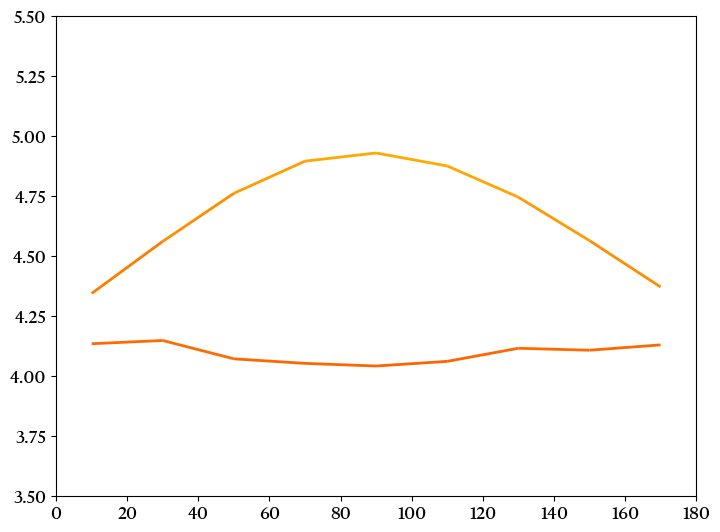

In [51]:
from matplotlib.collections import LineCollection

fig, ax = plt.subplots()

i_x = 135
# ax.plot(np.arange(10, 180, 20), [flux[96, i_x, i] for i in range(9)])

x = np.arange(10, 180, 20)
y = [flux[96, i_x, i] for i in range(9)]
c = y
pts = np.array([x, y]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap=ibm, norm=mpl.colors.Normalize(1, 5))
ax.add_collection(lc)
lc.set_array(c[:-1])
lc.set_linewidth(2)

i_x = 95
# ax.plot(np.arange(10, 180, 20), [flux[96, i_x, i] for i in range(9)])

x = np.arange(10, 180, 20)
y = [flux[96, i_x, i] for i in range(9)]
c = y
pts = np.array([x, y]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap=ibm, norm=mpl.colors.Normalize(1, 5))
ax.add_collection(lc)
lc.set_array(c[:-1])
lc.set_linewidth(2)

ax.set_xlim(0, 180)
ax.set_ylim(3.5, 5.5)

fig.tight_layout()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig("Plots/pad_plots_3_8_colored.pdf")

# 2D maps

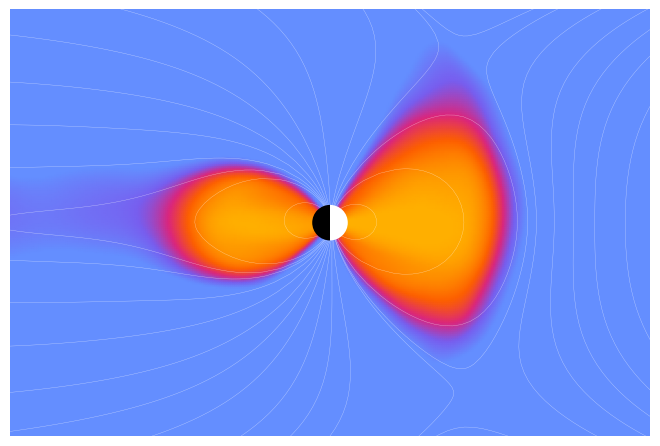

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(1)

# pcm = ax.pcolormesh(xs, zs, flux_o,
# pcm = ax.pcolormesh(xs, zs, flux_o_75-flux_o_25,
# pcm = ax.pcolormesh(xs, zs, flux_75[..., 0]-flux_25[..., 0],
# pcm = ax.pcolormesh(xs, zs, flux_75[..., 4]-flux_25[..., 4],
pcm = ax.pcolormesh(xs, zs, flux[..., 4],
                    shading='gouraud',
                    # shading='nearest',
                    cmap=ibm,
                    # cmap="viridis",
                    vmin=1.5, vmax=5,
                    # vmin=4, vmax=4.5
                    # vmin=7, vmax=9
                    # vmin=4, vmax=7
              )
 
if energy < 40000:
    ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none', zorder=100000))
ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none', zorder=100000))

for l in range(len(xxs)):
    ax.plot(xxs[l], zzs[l], linewidth=0.25, alpha=0.6, c='w')

# plt.plot(xs_bow, zs_bow, color='k', linestyle='--', linewidth=0.5)

ax.set_xlim(-18, 18)
ax.set_ylim(-12, 12)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# cbar = fig.colorbar(pcm, ax=ax, pad=0.02)

fig.tight_layout()

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig('Plots/angle_90.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/angle_90_iqr.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/energy_80000_xz_iqr.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/test.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/tilt_20_iqr.pdf', bbox_inches='tight', pad_inches=0)

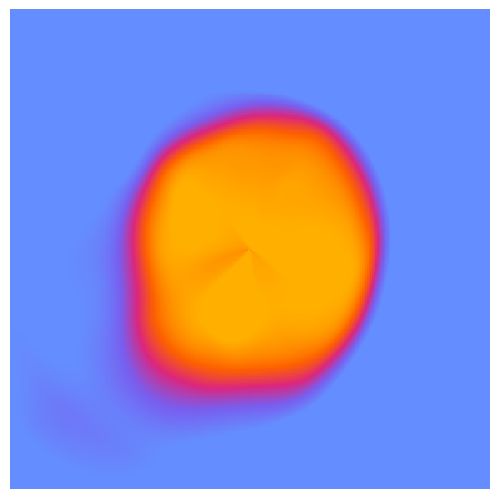

In [36]:
fig, ax = plt.subplots()
ax.set_aspect(1)

# ax.pcolormesh(xs, ys, flux_o,
ax.pcolormesh(xs, ys, flux[..., 4],
            #   shading='gouraud',
            #   shading='nearest',
              cmap=ibm,
            #   vmin=0, vmax=5
              vmin=2, vmax=5
            #   vmin=7, vmax=9
            #   vmin=4, vmax=7
              )

# plt.scatter(xs[160], ys[200])
# plt.scatter(xs[160], ys[240])

if energy < 40000:
    ax.add_patch(Circle((0, 0), 3, facecolor='w', edgecolor='none'))

# ax.add_patch(Wedge((0, 0), 1, -90, 90, facecolor='w', edgecolor='none'))
# ax.add_patch(Wedge((0, 0), 1, 90, 270, facecolor='k', edgecolor='none'))

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(-18, 18)
ax.set_ylim(-18, 18)

fig.tight_layout()

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# fig.savefig('Plots/energy_80000_xy.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/pitch_angle_90.pdf', bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/angle_50_xy.pdf', bbox_inches='tight', pad_inches=0)
fig.savefig('Plots/angle_90_xy.png', dpi=600, bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/tilt_20_xy.png', dpi=300, bbox_inches='tight', pad_inches=0)
# fig.savefig('Plots/tilt_20_xy.pdf', bbox_inches='tight', pad_inches=0)